In [1]:
import os
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

DATA_PATH = '/content/drive/MyDrive/ImpactSense_Oct25/data/preprocessed_earthquake_data_v3.csv'

In [2]:
import pandas as pd
import numpy as np
import folium
import geopandas as gpd
from shapely.geometry import Point

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf

In [4]:
df = pd.read_csv(DATA_PATH)

In [5]:
df.head()

,latitude,longitude,depth,mag,magType,rms,type,status,Year,Month,Day,Hour,Minute,Second,DayOfWeek,Mw,damage_potential
0,41.758,23.249,-0.430517,3.296720,mw,0.255959,earthquake,reviewed,1904,4,4,10,26,0,0,7.02,10.0
1,41.802,23.108,-0.430517,2.920854,mw,0.227615,earthquake,reviewed,1904,4,4,10,2,34,0,6.84,10.0
2,52.763,160.277,-0.291162,4.716657,mw,0.360656,earthquake,reviewed,1904,6,25,21,0,38,5,7.70,10.0
3,51.424,161.638,-0.430517,4.299028,mw,0.331543,earthquake,reviewed,1904,6,25,14,45,39,5,7.50,10.0
4,30.684,100.608,-0.430517,3.442890,mw,0.266982,earthquake,reviewed,1904,8,30,11,43,20,1,7.09,10.0


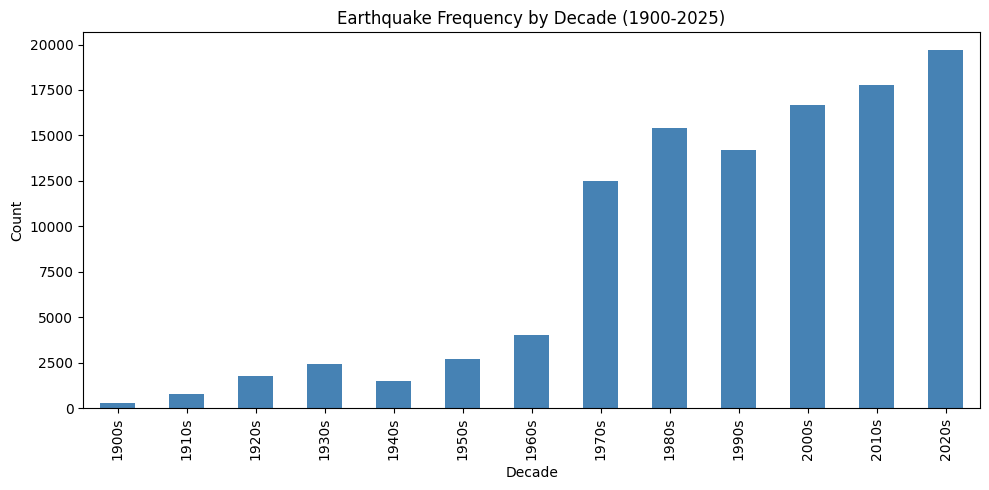

In [6]:
plt.figure(figsize=(10,5))

start_year = 1900
end_year = 2025

df_filtered = df[(df['Year'] >= start_year) & (df['Year'] <= end_year)].copy()
df_filtered['Decade'] = (df_filtered['Year'] // 10) * 10
df_filtered['Decade'] = df_filtered['Decade'].astype(str) + 's'

df_filtered['Decade'].value_counts().sort_index().plot(kind='bar', color='steelblue')
plt.title(f'Earthquake Frequency by Decade ({start_year}-{end_year})')
plt.xlabel('Decade')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

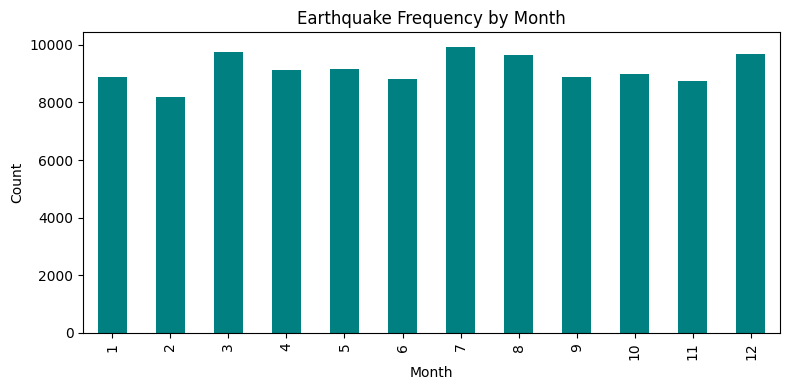

In [7]:
# Earthquake frequency by Month
plt.figure(figsize=(8,4))
df['Month'].value_counts().sort_index().plot(kind='bar', color='teal')
plt.title('Earthquake Frequency by Month')
plt.xlabel('Month')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

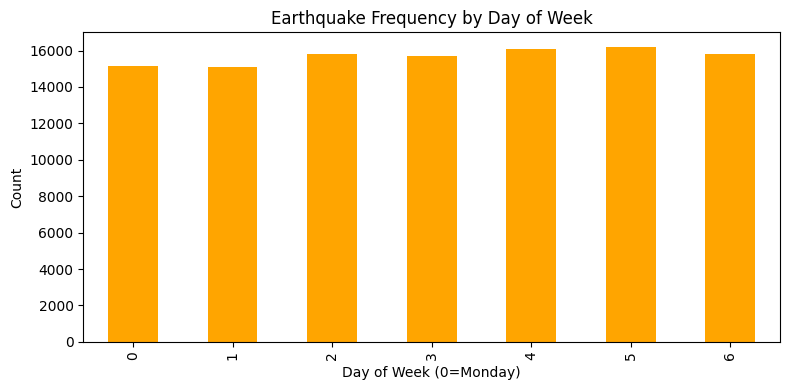

In [8]:
# Earthquake frequency by DayOfWeek
plt.figure(figsize=(8,4))
df['DayOfWeek'].value_counts().sort_index().plot(kind='bar', color='orange')
plt.title('Earthquake Frequency by Day of Week')
plt.xlabel('Day of Week (0=Monday)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

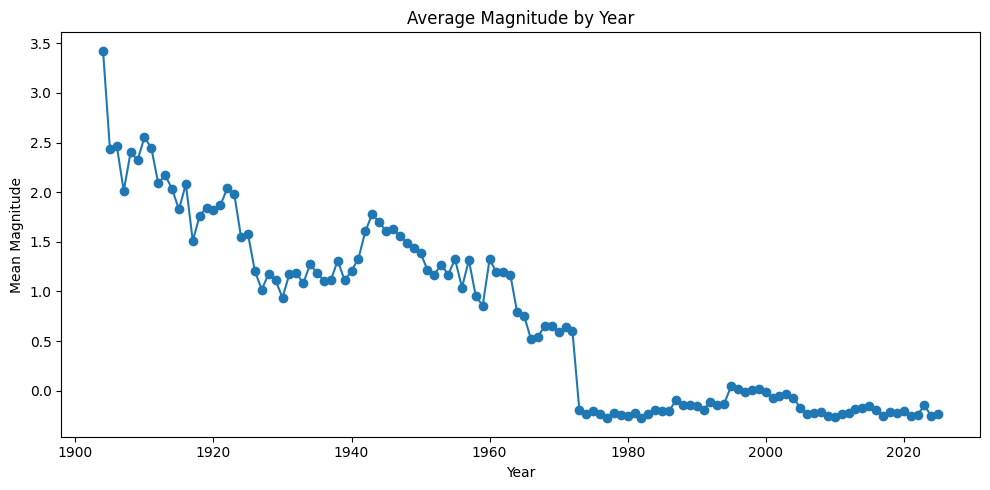

In [9]:
temporal_stats = {}
if 'mag' in df.columns:
  temporal_stats['mean_mag_by_year'] = df.groupby('Year')['mag'].mean()
if 'damage_potential' in df.columns:
  temporal_stats['mean_damage_by_year'] = df.groupby('Year')['damage_potential'].mean()


# Plot time series: mean magnitude over years
if 'mag' in df.columns:
  plt.figure(figsize=(10,5))
  df.groupby('Year')['mag'].mean().plot(marker='o')
  plt.title('Average Magnitude by Year')
  plt.xlabel('Year')
  plt.ylabel('Mean Magnitude')
  plt.tight_layout()
  plt.show()


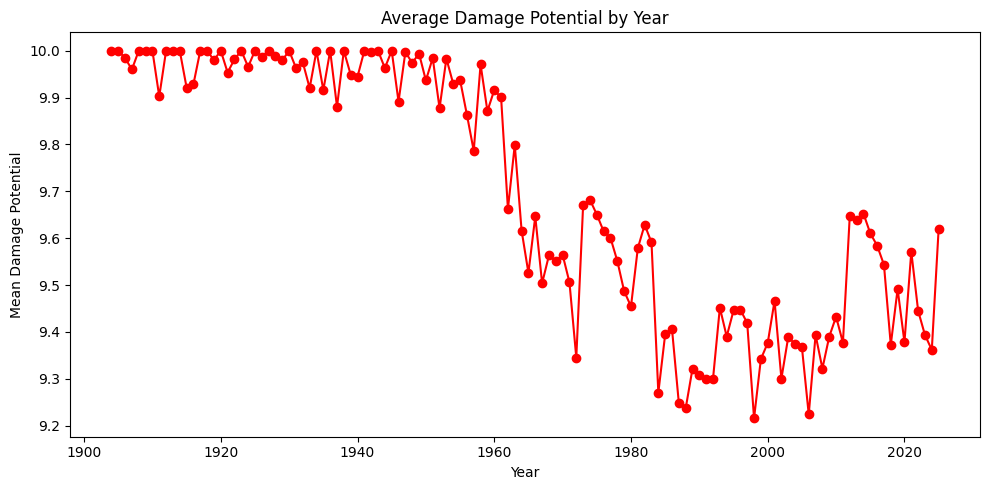

In [10]:
# Plot time series: mean damage potential over years
if 'damage_potential' in df.columns:
  plt.figure(figsize=(10,5))
  df.groupby('Year')['damage_potential'].mean().plot(marker='o', color='red')
  plt.title('Average Damage Potential by Year')
  plt.xlabel('Year')
  plt.ylabel('Mean Damage Potential')
  plt.tight_layout()
  plt.show()

Visualize time series of earthquake counts and average magnitude over years

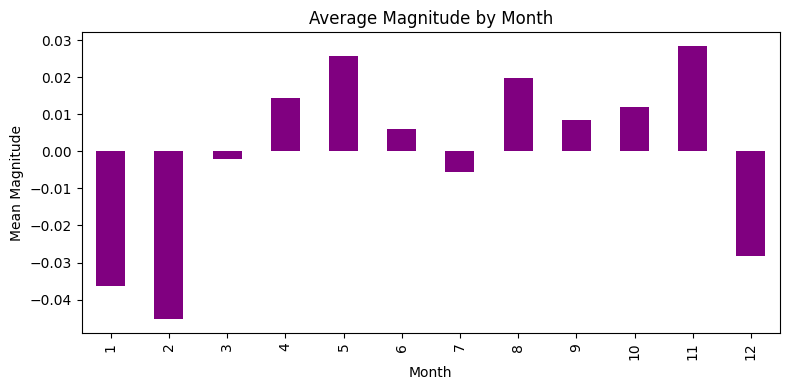

In [11]:
# Mean magnitude and damage potential by Month
if 'mag' in df.columns:
  plt.figure(figsize=(8,4))
  df.groupby('Month')['mag'].mean().plot(kind='bar', color='purple')
  plt.title('Average Magnitude by Month')
  plt.xlabel('Month')
  plt.ylabel('Mean Magnitude')
  plt.tight_layout()
  plt.show()

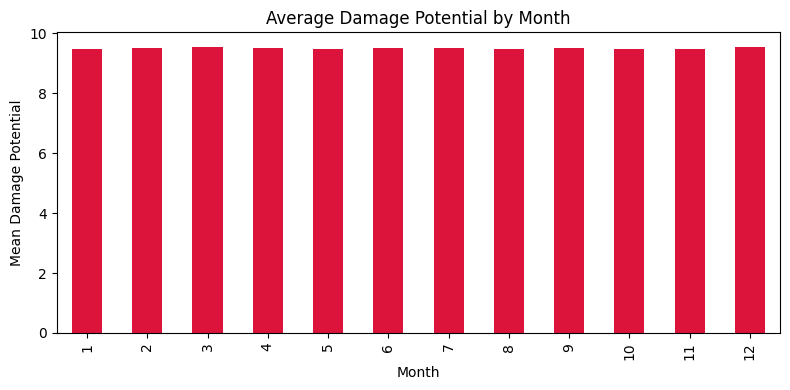

In [12]:
if 'damage_potential' in df.columns:
  plt.figure(figsize=(8,4))
  df.groupby('Month')['damage_potential'].mean().plot(kind='bar', color='crimson')
  plt.title('Average Damage Potential by Month')
  plt.xlabel('Month')
  plt.ylabel('Mean Damage Potential')
  plt.tight_layout()
  plt.show()

Create heatmap of earthquakes by Month and DayOfWeek

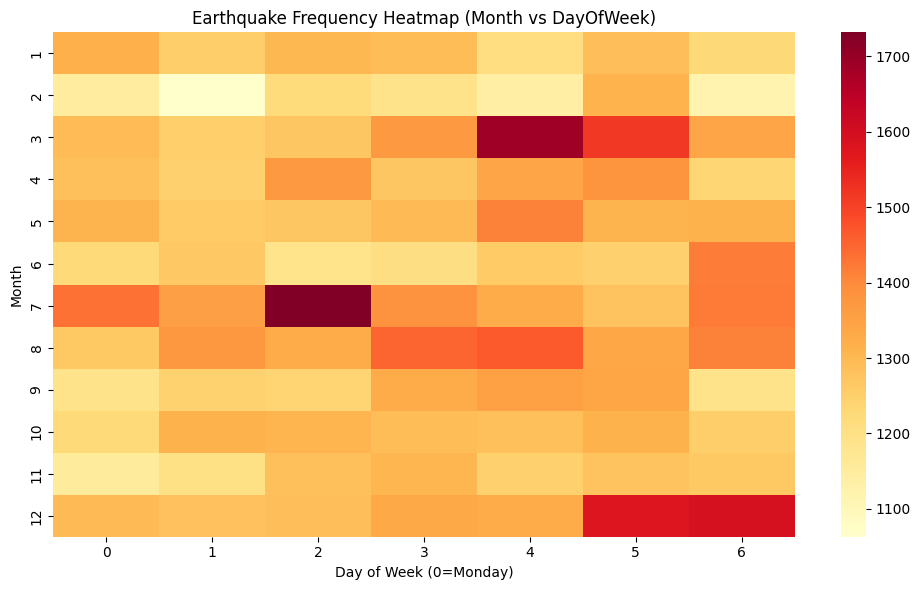

In [13]:
heat_df = df.groupby(['Month','DayOfWeek']).size().unstack(fill_value=0)
plt.figure(figsize=(10,6))
sns.heatmap(heat_df, cmap='YlOrRd', annot=False)
plt.title('Earthquake Frequency Heatmap (Month vs DayOfWeek)')
plt.xlabel('Day of Week (0=Monday)')
plt.ylabel('Month')
plt.tight_layout()
plt.show()

Task 2: Geographical Distribution Analysis

Generate scatter plot of latitude vs. longitude colored by magnitude or damage_potential

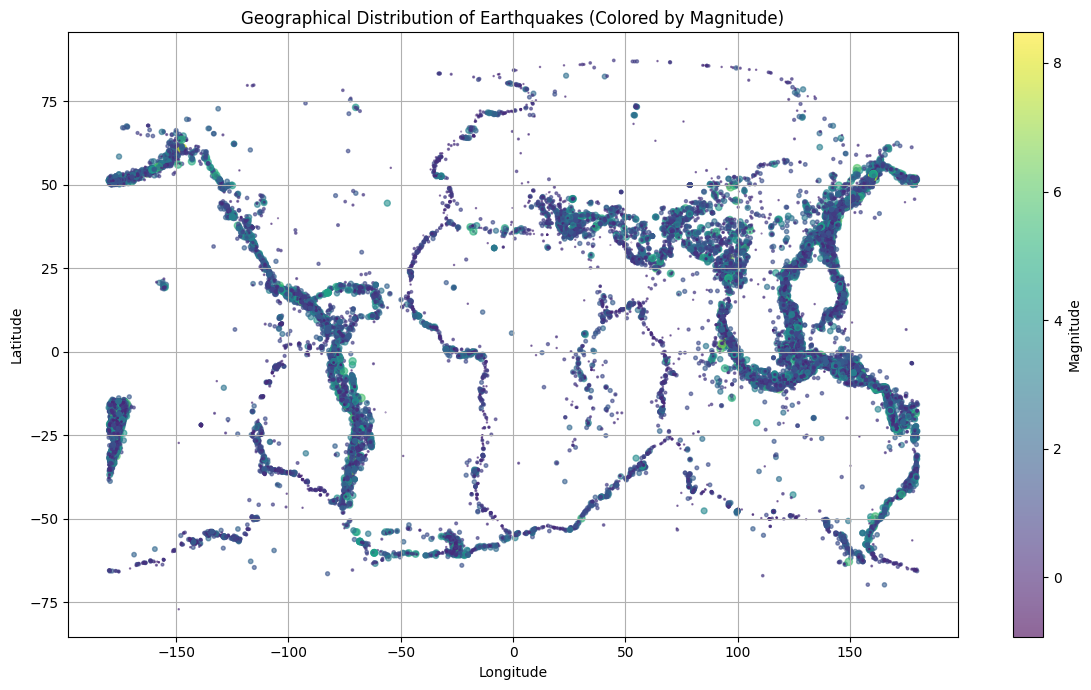

In [14]:
plt.figure(figsize=(12, 7))
scatter = plt.scatter(df['longitude'], df['latitude'], c=df['mag'], cmap='viridis', s=df['mag']*5, alpha=0.6)
plt.colorbar(scatter, label='Magnitude')
plt.title('Geographical Distribution of Earthquakes (Colored by Magnitude)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.grid(True)
plt.tight_layout()
plt.show()

Create density maps or 2D histograms showing earthquake hotspots

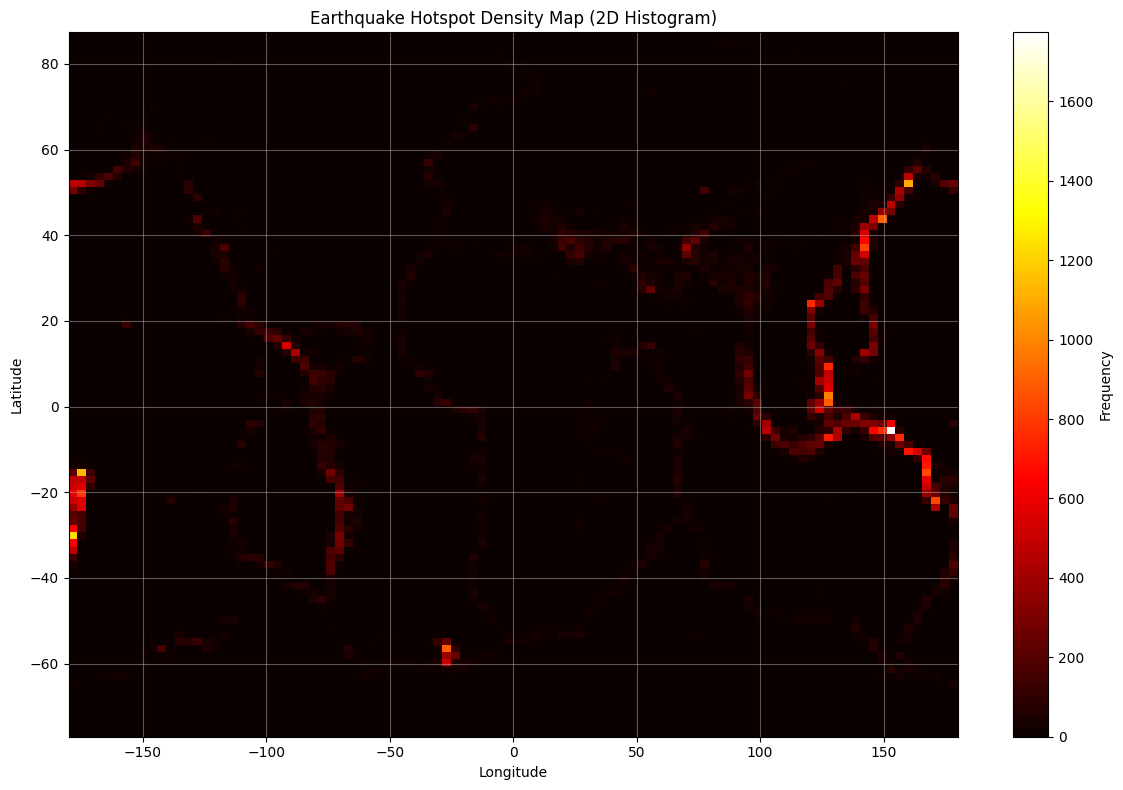

In [15]:
plt.figure(figsize=(12, 8))
plt.hist2d(df['longitude'], df['latitude'], bins=100, cmap='hot')
plt.colorbar(label='Frequency')
plt.title('Earthquake Hotspot Density Map (2D Histogram)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.grid(True, alpha=0.5)
plt.tight_layout()
plt.show()

Analyze earthquake distribution by geographical regions (latitude/longitude bins)

In [16]:
# Define latitude and longitude bins
lat_bins = np.arange(-90, 91, 10)
lon_bins = np.arange(-180, 181, 20)

# Create new columns for latitude and longitude bins
df['latitude_bin'] = pd.cut(df['latitude'], bins=lat_bins, labels=lat_bins[:-1], include_lowest=True)
df['longitude_bin'] = pd.cut(df['longitude'], bins=lon_bins, labels=lon_bins[:-1], include_lowest=True)

# Analyze earthquake distribution by geographical regions
geo_distribution = df.groupby(['latitude_bin', 'longitude_bin']).agg(
    count=('latitude', 'size'),
    mean_mag=('mag', 'mean'),
    mean_damage_potential=('damage_potential', 'mean')
).reset_index()

# Display the results
display(geo_distribution.head())

,latitude_bin,longitude_bin,count,mean_mag,mean_damage_potential
0,-90,-180,0,NaN,NaN
1,-90,-160,0,NaN,NaN
2,-90,-140,0,NaN,NaN
3,-90,-120,0,NaN,NaN
4,-90,-100,0,NaN,NaN


Calculate correlation between geographical coordinates and seismic characteristics

In [17]:
# Calculate correlation between geographical coordinates and seismic characteristics
correlation_matrix = df[['latitude', 'longitude', 'mag', 'damage_potential']].corr()

# Display the correlation matrix
display(correlation_matrix)

,latitude,longitude,mag,damage_potential
latitude,1.000000,0.213085,0.044229,0.098566
longitude,0.213085,1.000000,-0.002900,0.093421
mag,0.044229,-0.002900,1.000000,0.031456
damage_potential,0.098566,0.093421,0.031456,1.000000


Identify high-risk geographical areas based on damage_potential

In [18]:
# Identify high-risk geographical areas based on damage_potential
high_risk_areas = geo_distribution.sort_values(by='mean_damage_potential', ascending=False)

# Display the top high-risk areas
print("Top High-Risk Geographical Areas based on Average Damage Potential:")
display(high_risk_areas.head())

Top High-Risk Geographical Areas based on Average Damage Potential:


,latitude_bin,longitude_bin,count,mean_mag,mean_damage_potential
19,-80,-160,1,0.122744,10.0
20,-80,-140,1,-0.921328,10.0
21,-80,-120,1,-0.294885,10.0
35,-80,160,1,-0.712513,10.0
36,-70,-180,85,0.049536,10.0


 Magnitude and Damage Potential Relationship

Create scatter plot: Magnitude (mag) vs. Damage Potential with depth color-coding

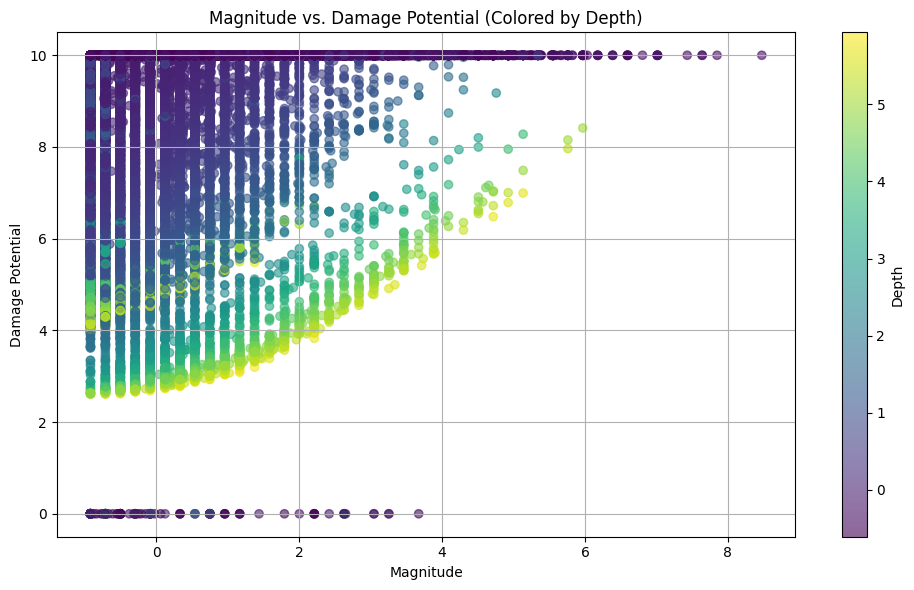

In [19]:
plt.figure(figsize=(10, 6))
scatter = plt.scatter(df['mag'], df['damage_potential'], c=df['depth'], cmap='viridis', alpha=0.6)
plt.colorbar(scatter, label='Depth')
plt.title('Magnitude vs. Damage Potential (Colored by Depth)')
plt.xlabel('Magnitude')
plt.ylabel('Damage Potential')
plt.grid(True)
plt.tight_layout()
plt.show()

Plot Moment Magnitude (Mw) vs. Damage Potential

Generate distribution histograms for mag, Mw, and damage_potential (with KDE)


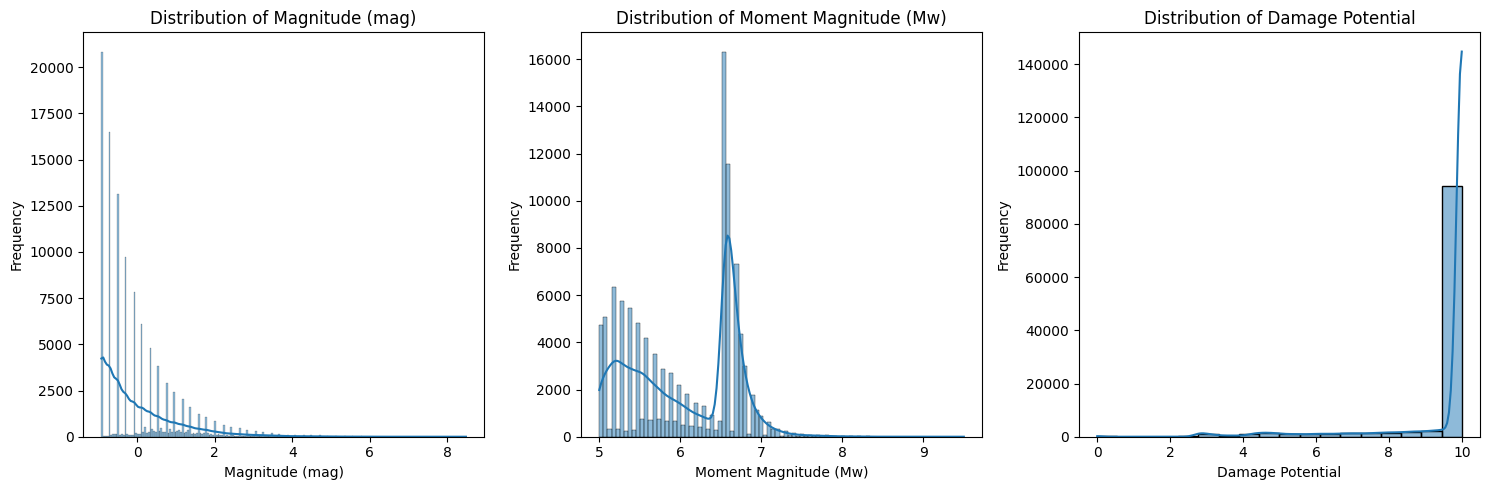

In [20]:

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
sns.histplot(df['mag'], kde=True)
plt.title('Distribution of Magnitude (mag)')
plt.xlabel('Magnitude (mag)')
plt.ylabel('Frequency')

plt.subplot(1, 3, 2)
sns.histplot(df['Mw'], kde=True)
plt.title('Distribution of Moment Magnitude (Mw)')
plt.xlabel('Moment Magnitude (Mw)')
plt.ylabel('Frequency')

plt.subplot(1, 3, 3)
sns.histplot(df['damage_potential'], kde=True)
plt.title('Distribution of Damage Potential')
plt.xlabel('Damage Potential')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

Calculate correlation coefficients (Pearson and Spearman) between mag/Mw and
damage_potential

In [21]:
# df = pd.read_csv(DATA_PATH)

# Calculate Pearson correlation coefficients
pearson_corr_mag = df['mag'].corr(df['damage_potential'], method='pearson')
pearson_corr_mw = df['Mw'].corr(df['damage_potential'], method='pearson')

print(f"Pearson correlation between Magnitude (mag) and Damage Potential: {pearson_corr_mag:.4f}")
print(f"Pearson correlation between Moment Magnitude (Mw) and Damage Potential: {pearson_corr_mw:.4f}")

# Calculate Spearman correlation coefficients
spearman_corr_mag = df['mag'].corr(df['damage_potential'], method='spearman')
spearman_corr_mw = df['Mw'].corr(df['damage_potential'], method='spearman')

print(f"\nSpearman correlation between Magnitude (mag) and Damage Potential: {spearman_corr_mag:.4f}")
print(f"Spearman correlation between Moment Magnitude (Mw) and Damage Potential: {spearman_corr_mw:.4f}")

Pearson correlation between Magnitude (mag) and Damage Potential: 0.0315
Pearson correlation between Moment Magnitude (Mw) and Damage Potential: 0.1308

Spearman correlation between Magnitude (mag) and Damage Potential: 0.0465
Spearman correlation between Moment Magnitude (Mw) and Damage Potential: 0.1664


Analyze outliers and their characteristics

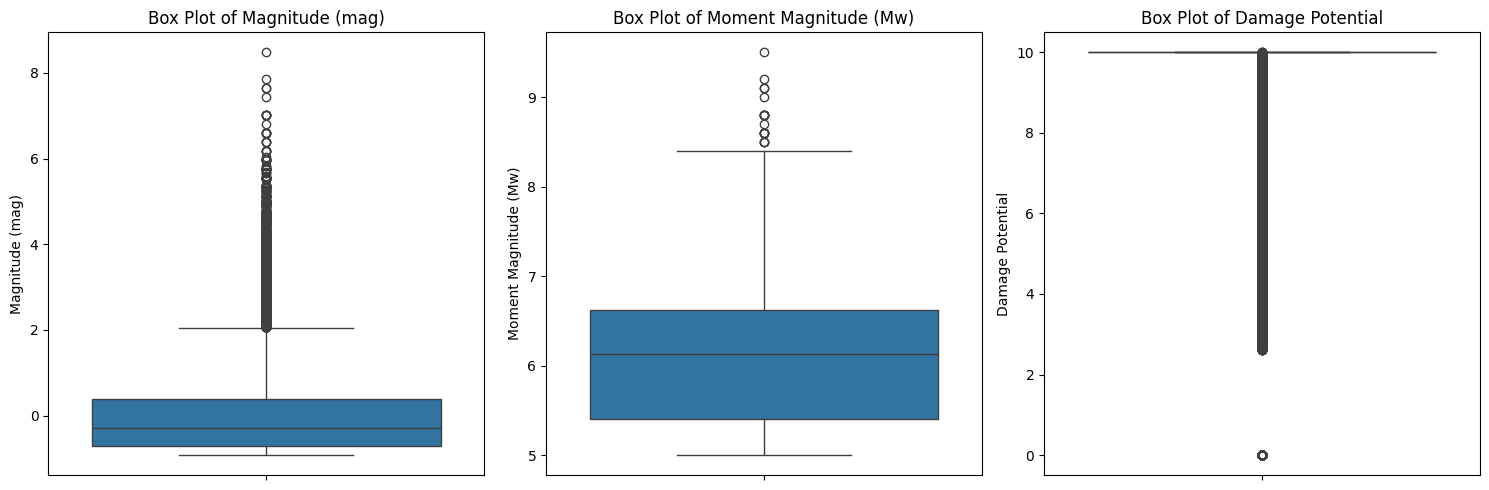


To further analyze outliers, you can use methods like calculating z-scores or filtering the DataFrame based on values outside a certain range (e.g., beyond the whiskers in the box plot).


In [22]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
sns.boxplot(y=df['mag'])
plt.title('Box Plot of Magnitude (mag)')
plt.ylabel('Magnitude (mag)')

plt.subplot(1, 3, 2)
sns.boxplot(y=df['Mw'])
plt.title('Box Plot of Moment Magnitude (Mw)')
plt.ylabel('Moment Magnitude (Mw)')

plt.subplot(1, 3, 3)
sns.boxplot(y=df['damage_potential'])
plt.title('Box Plot of Damage Potential')
plt.ylabel('Damage Potential')

plt.tight_layout()
plt.show()

print("\nTo further analyze outliers, you can use methods like calculating z-scores or filtering the DataFrame based on values outside a certain range (e.g., beyond the whiskers in the box plot).")

Depth Analysis and Its Impact

Create box plots: Depth vs. Magnitude (stratified by depth ranges: shallow, intermediate, deep)

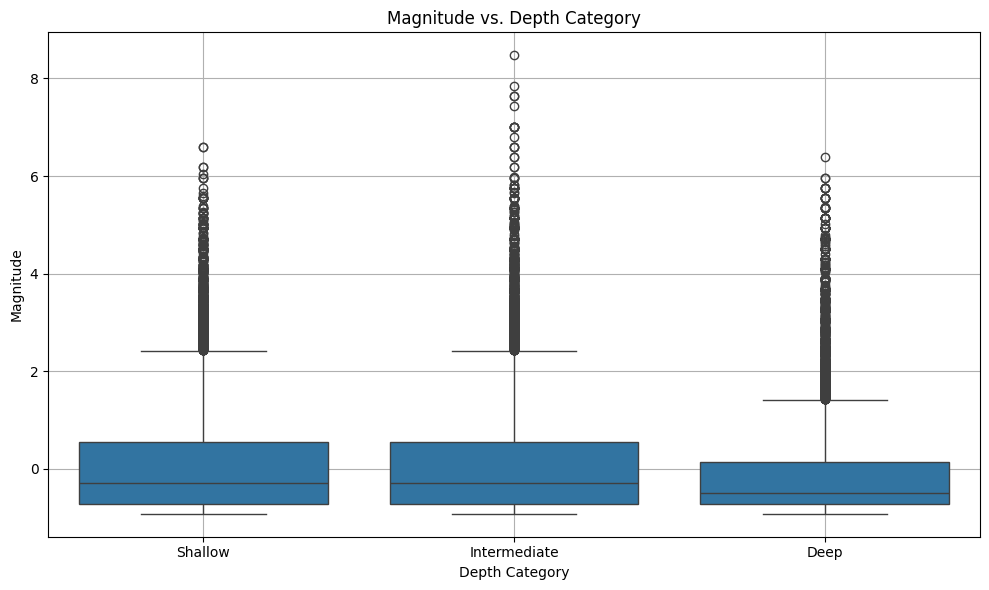

In [23]:
import seaborn as sns
# Using quantiles to define ranges based on data distribution

depth_quantiles = df['depth'].quantile([0.33, 0.66])
shallow_threshold = depth_quantiles.iloc[0]
intermediate_threshold = depth_quantiles.iloc[1]

def depth_range(depth):
    if depth <= shallow_threshold:
        return 'Shallow'
    elif depth <= intermediate_threshold:
        return 'Intermediate'
    else:
        return 'Deep'

df['depth_category'] = df['depth'].apply(depth_range)

# Create box plot of Depth vs. Magnitude stratified by depth ranges
plt.figure(figsize=(10, 6))
sns.boxplot(x='depth_category', y='mag', data=df, order=['Shallow', 'Intermediate', 'Deep'])
plt.title('Magnitude vs. Depth Category')
plt.xlabel('Depth Category')
plt.ylabel('Magnitude')
plt.grid(True)
plt.tight_layout()
plt.show()

Analyze depth distribution with histogram and statistics (mean, median, std)

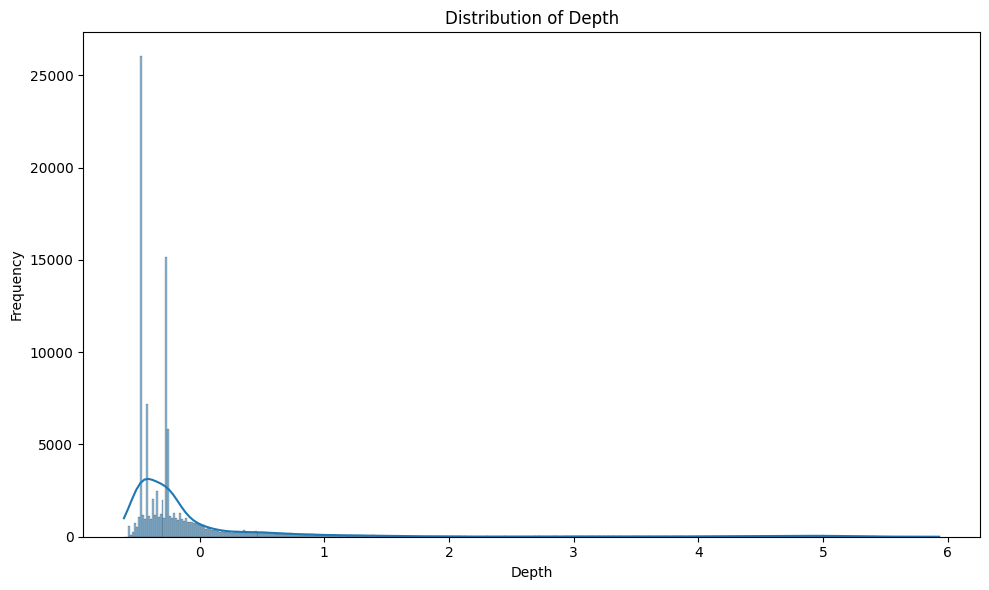


Descriptive Statistics for Depth:


,depth
count,1.098480e+05
mean,-9.314521e-17
std,1.000005e+00
min,-6.070324e-01
25%,-4.769683e-01
50%,-2.632915e-01
75%,-9.606619e-02
max,5.933336e+00


In [24]:
# Analyze depth distribution with a histogram
plt.figure(figsize=(10, 6))
sns.histplot(df['depth'], kde=True)
plt.title('Distribution of Depth')
plt.xlabel('Depth')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

# Analyze depth distribution with statistics
print("\nDescriptive Statistics for Depth:")
display(df['depth'].describe())

Plot depth vs. damage_potential using scatter and 2D density plots

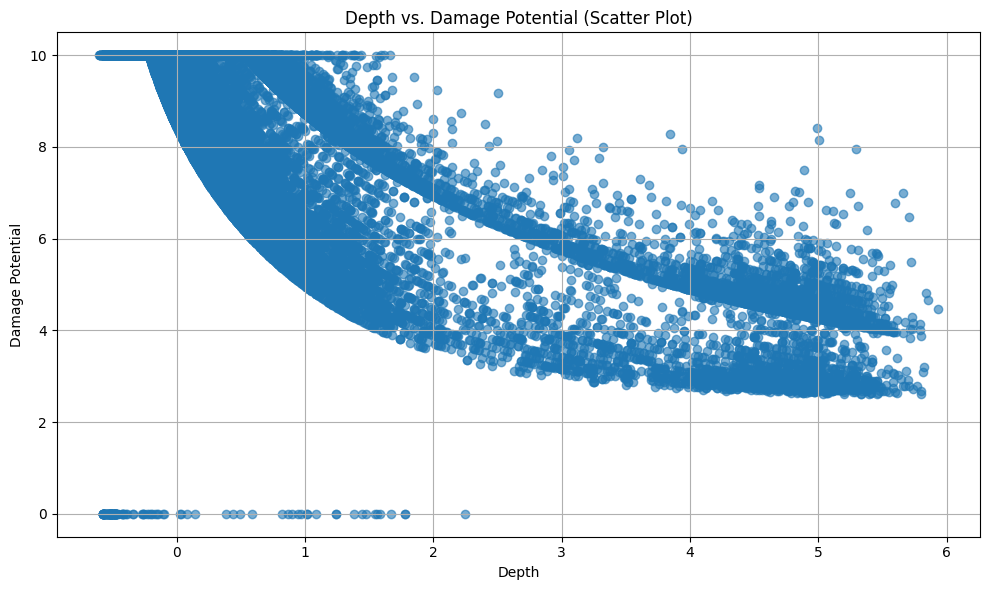

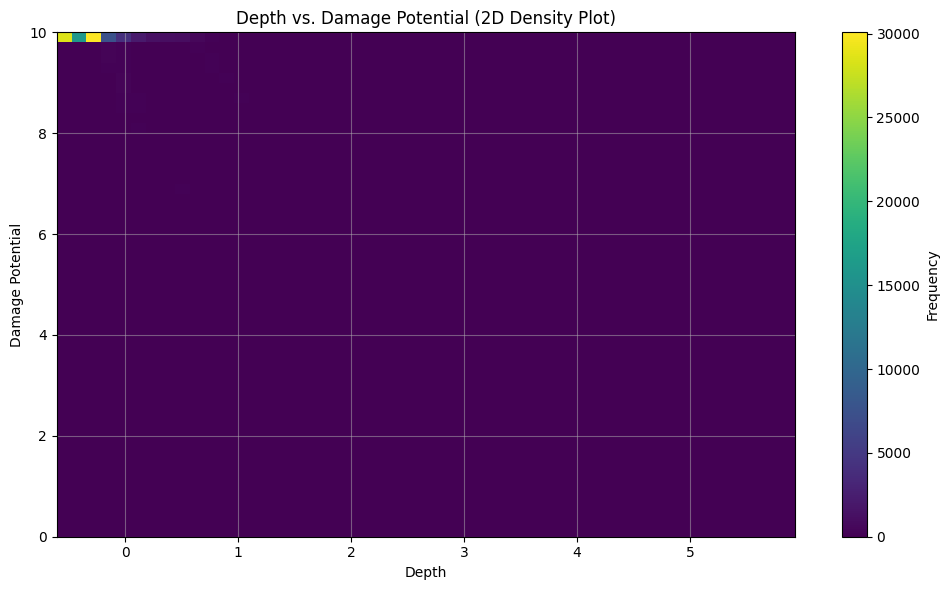

In [25]:
# Create scatter plot of Depth vs. Damage Potential
plt.figure(figsize=(10, 6))
plt.scatter(df['depth'], df['damage_potential'], alpha=0.6)
plt.title('Depth vs. Damage Potential (Scatter Plot)')
plt.xlabel('Depth')
plt.ylabel('Damage Potential')
plt.grid(True)
plt.tight_layout()
plt.show()

# Create 2D density plot (heatmap) of Depth vs. Damage Potential
plt.figure(figsize=(10, 6))
plt.hist2d(df['depth'], df['damage_potential'], bins=50, cmap='viridis')
plt.colorbar(label='Frequency')
plt.title('Depth vs. Damage Potential (2D Density Plot)')
plt.xlabel('Depth')
plt.ylabel('Damage Potential')
plt.grid(True, alpha=0.5)
plt.tight_layout()
plt.show()

Calculate mean damage_potential by depth category

In [26]:
# Calculate mean damage potential by depth category
mean_damage_by_depth = df.groupby('depth_category')['damage_potential'].mean().reset_index()

# Display the results
print("Mean Damage Potential by Depth Category:")
display(mean_damage_by_depth)

Mean Damage Potential by Depth Category:


,depth_category,damage_potential
0,Deep,8.551149
1,Intermediate,9.996264
2,Shallow,9.978040


Identify whether shallow or deep earthquakes cause more damage

In [27]:
# Assuming mean_damage_by_depth DataFrame is available from the previous step (cn6GulwDJ--k)
# If not, you might need to recalculate it:
# import pandas as pd
# # Assuming df is already loaded and 'depth_category' column is created
# mean_damage_by_depth = df.groupby('depth_category')['damage_potential'].mean().reset_index()

shallow_damage = mean_damage_by_depth[mean_damage_by_depth['depth_category'] == 'Shallow']['damage_potential'].values[0]
deep_damage = mean_damage_by_depth[mean_damage_by_depth['depth_category'] == 'Deep']['damage_potential'].values[0]

print(f"Mean Damage Potential for Shallow Earthquakes: {shallow_damage:.4f}")
print(f"Mean Damage Potential for Deep Earthquakes: {deep_damage:.4f}")

if shallow_damage > deep_damage:
    print("\nBased on the mean damage potential in this dataset, shallow earthquakes tend to cause more damage than deep earthquakes.")
elif deep_damage > shallow_damage:
    print("\nBased on the mean damage potential in this dataset, deep earthquakes tend to cause more damage than shallow earthquakes.")
else:
    print("\nBased on the mean damage potential in this dataset, shallow and deep earthquakes cause a similar amount of damage.")

Mean Damage Potential for Shallow Earthquakes: 9.9780
Mean Damage Potential for Deep Earthquakes: 8.5511

Based on the mean damage potential in this dataset, shallow earthquakes tend to cause more damage than deep earthquakes.


Categorical Feature Analysis

In [28]:
# 1. Analyze value counts for magType, type, and status columns
print("Value counts for magType:")
display(df['magType'].value_counts())

print("\nValue counts for type:")
display(df['type'].value_counts())

print("\nValue counts for status:")
display(df['status'].value_counts())


Value counts for magType:


,count
magType,
mb,45084
mw,24335
mwc,17458
mww,15652
ms,3157
mwb,3082
ml,485
mwr,451
md,50



Value counts for type:


,count
type,
earthquake,109356
nuclear explosion,424
volcanic eruption,54
explosion,10
landslide,2
mine collapse,1
rock burst,1



Value counts for status:


,count
status,
reviewed,109744
automatic,104


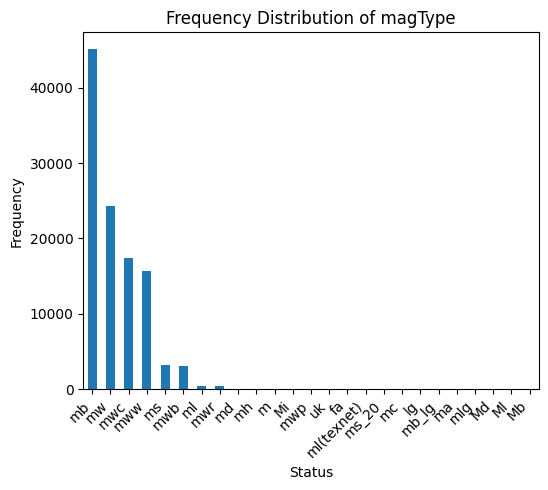

In [29]:
# 2. Create bar charts showing frequency distribution of each categorical variable
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
df['magType'].value_counts().plot(kind='bar')
plt.title('Frequency Distribution of magType')
plt.xlabel('Magnitude Type')
plt.ylabel('Frequency')
plt.xticks(rotation=45, ha='right')
plt.xlabel('Status')
plt.ylabel('Frequency')
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

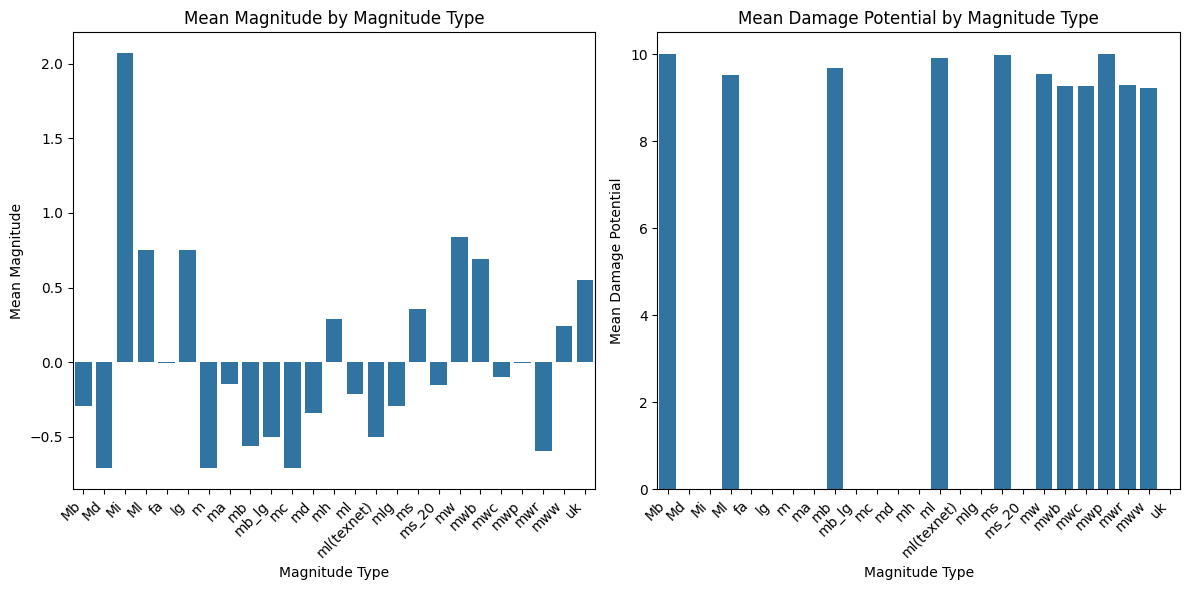

In [30]:
# 3. Generate grouped bar charts: magType vs. mean magnitude and damage_potential
magtype_analysis = df.groupby('magType')[['mag', 'damage_potential']].mean().reset_index()

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
sns.barplot(x='magType', y='mag', data=magtype_analysis)
plt.title('Mean Magnitude by Magnitude Type')
plt.xlabel('Magnitude Type')
plt.ylabel('Mean Magnitude')
plt.xticks(rotation=45, ha='right')

plt.subplot(1, 2, 2)
sns.barplot(x='magType', y='damage_potential', data=magtype_analysis)
plt.title('Mean Damage Potential by Magnitude Type')
plt.xlabel('Magnitude Type')
plt.ylabel('Mean Damage Potential')
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

In [31]:
# 4. Create cross-tabulation (contingency tables) between categorical variables

print("\nCross-tabulation between Type and Status:")
display(pd.crosstab(df['type'], df['status']))

print("\nCross-tabulation between magType and Status:")
display(pd.crosstab(df['magType'], df['status']))

print("\nCross-tabulation between Type and magType:")
display(pd.crosstab(df['type'], df['magType']))


Cross-tabulation between Type and Status:


status,automatic,reviewed
type,,
earthquake,104,109252
explosion,0,10
landslide,0,2
mine collapse,0,1
nuclear explosion,0,424
rock burst,0,1
volcanic eruption,0,54



Cross-tabulation between magType and Status:


status,automatic,reviewed
magType,,
Mb,0,1
Md,0,1
Mi,0,12
Ml,0,1
fa,0,5
lg,0,1
m,0,21
ma,0,1
mb,0,45084



Cross-tabulation between Type and magType:


magType,Mb,Md,Mi,Ml,fa,lg,m,ma,mb,mb_lg,...,mlg,ms,ms_20,mw,mwb,mwc,mwp,mwr,mww,uk
type,,,,,,,,,,,,,,,,,,,,,
earthquake,1,1,12,1,5,1,21,1,44669,1,...,1,3155,2,24281,3082,17458,9,451,15650,8
explosion,0,0,0,0,0,0,0,0,10,0,...,0,0,0,0,0,0,0,0,0,0
landslide,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,2,0
mine collapse,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
nuclear explosion,0,0,0,0,0,0,0,0,404,0,...,0,2,0,1,0,0,0,0,0,0
rock burst,0,0,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
volcanic eruption,0,0,0,0,0,0,0,0,0,0,...,0,0,1,53,0,0,0,0,0,0


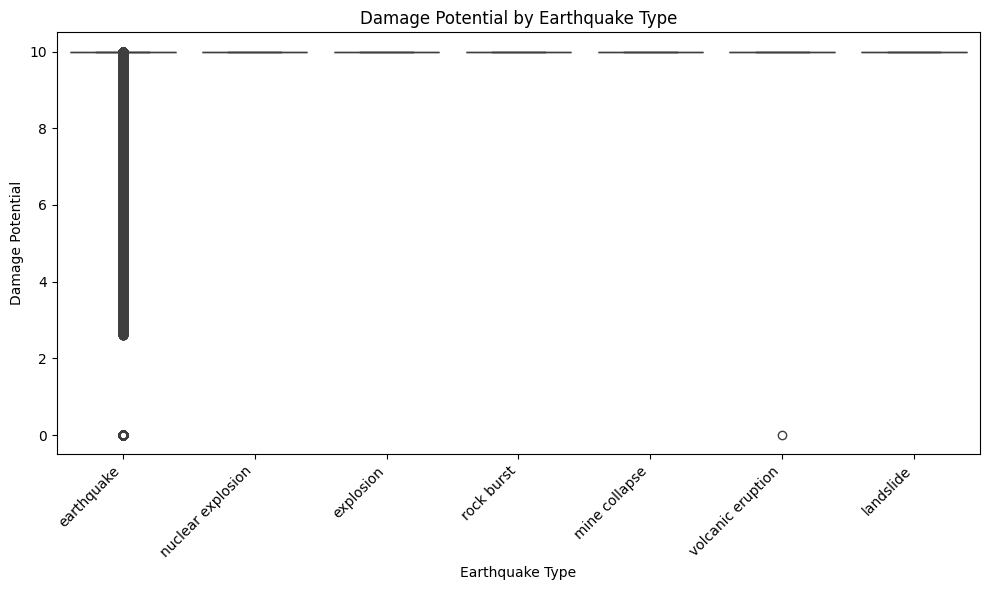

In [32]:
# 5. Visualize earthquake type distribution and its association with damage_potential
plt.figure(figsize=(10, 6))
sns.boxplot(x='type', y='damage_potential', data=df)
plt.title('Damage Potential by Earthquake Type')
plt.xlabel('Earthquake Type')
plt.ylabel('Damage Potential')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [33]:
!pip install scipy

In [34]:
from scipy.stats import chi2_contingency
import numpy as np

def cramers_v(x, y):
    """Calculate Cramér's V statistic for categorical variables."""
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    v = np.sqrt(phi2 / min(k - 1, r - 1))
    return v

# Calculate Cramér's V for pairs of categorical variables
cramers_v_type_status = cramers_v(df['type'], df['status'])
cramers_v_magType_status = cramers_v(df['magType'], df['status'])
cramers_v_type_magType = cramers_v(df['type'], df['magType'])

print(f"Cramér's V between Type and Status: {cramers_v_type_status:.4f}")
print(f"Cramér's V between magType and Status: {cramers_v_magType_status:.4f}")
print(f"Cramér's V between Type and magType: {cramers_v_type_magType:.4f}")

# You can also create a Cramér's V matrix for multiple variables if needed
# For example, for 'type', 'magType', and 'status':
# categorical_vars = ['type', 'magType', 'status']
# cramers_matrix = pd.DataFrame(index=categorical_vars, columns=categorical_vars)
# for var1 in categorical_vars:
#     for var2 in categorical_vars:
#         if var1 == var2:
#             cramers_matrix.loc[var1, var2] = 1.0
#         else:
#             cramers_matrix.loc[var1, var2] = cramers_v(df[var1], df[var2])

# print("\nCramér's V Matrix:")
# display(cramers_matrix)

Cramér's V between Type and Status: 0.0021
Cramér's V between magType and Status: 0.0607
Cramér's V between Type and magType: 0.0520


## Notebook Summary

This notebook performs an exploratory data analysis of earthquake data. The analysis covers several aspects:

*1. Data Loading and Initial Inspection:*
- The notebook starts by loading the preprocessed earthquake data from a CSV file into a pandas DataFrame.
- The head of the DataFrame is displayed to get a glimpse of the data structure and columns.

*2. Temporal Analysis:*
- Earthquake frequency is analyzed over different time periods: by decade, month, and day of the week. Bar plots are used to visualize these frequencies.
- Time series plots are generated to show the average magnitude and average damage potential over the years.
- Mean magnitude and damage potential are also analyzed by month using bar plots.
- A heatmap is created to visualize the earthquake frequency by month and day of the week, highlighting potential patterns.

*3. Geographical Distribution Analysis:*
- A scatter plot is used to visualize the geographical distribution of earthquakes, with points colored and sized by magnitude.
- A 2D histogram (density map) is generated to show earthquake hotspots.
- The earthquake distribution is analyzed by geographical regions (latitude/longitude bins), and the count, mean magnitude, and mean damage potential are calculated for each region.
- The correlation between geographical coordinates and seismic characteristics (magnitude and damage potential) is calculated and displayed as a correlation matrix.
- High-risk geographical areas are identified based on the average damage potential.

*4. Magnitude and Damage Potential Relationship:*
- A scatter plot is created to show the relationship between magnitude and damage potential, with depth color-coding.
- Distribution histograms with KDE are generated for magnitude, moment magnitude (Mw), and damage potential to understand their distributions.
- Pearson and Spearman correlation coefficients are calculated between magnitude/Mw and damage potential to quantify their linear and rank correlations.
- Box plots are used to analyze outliers in magnitude, Mw, and damage potential.

*5. Depth Analysis and Its Impact:*
- The depth column is categorized into 'Shallow', 'Intermediate', and 'Deep' based on quantiles.
- Box plots are created to visualize the relationship between depth category and magnitude.
- The distribution of depth is analyzed with a histogram and descriptive statistics (mean, median, std).
- Scatter and 2D density plots are used to visualize the relationship between depth and damage potential.
- The mean damage potential is calculated for each depth category.
- A conclusion is drawn about whether shallow or deep earthquakes tend to cause more damage based on the mean damage potential in the dataset.

*6. Categorical Feature Analysis:*
- Value counts are displayed for categorical columns: magType, type, and status.
- Bar charts are generated to show the frequency distribution of each categorical variable.
- Grouped bar charts are created to analyze the mean magnitude and mean damage potential by magType.
- Cross-tabulations (contingency tables) are generated between pairs of categorical variables (type vs. status, magType vs. status, and type vs. magType).
- A box plot is used to visualize the damage potential by earthquake type.
- Cramér's V statistic is calculated to measure the association between categorical variables.